
# Exploration et Démonstration du Projet Titanic

Ce notebook combine l'analyse exploratoire des données (EDA) et l'exécution complète du pipeline de modélisation.


In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

from infrastructure.cleaning import clean_data
from domain.pipeline import prepare_data
from domain.models import train_model, evaluate_model, save_model
%matplotlib inline

In [2]:

# Chargement des données brutes
train_data = pd.read_csv('../../../data/raw/train.csv', encoding='utf-8')
print('Aperçu des données brutes:')
print(train_data.head())


Aperçu des données brutes:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450  

In [3]:
# Statistiques descriptives
print(train_data.describe())
print(train_data.info())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data colu

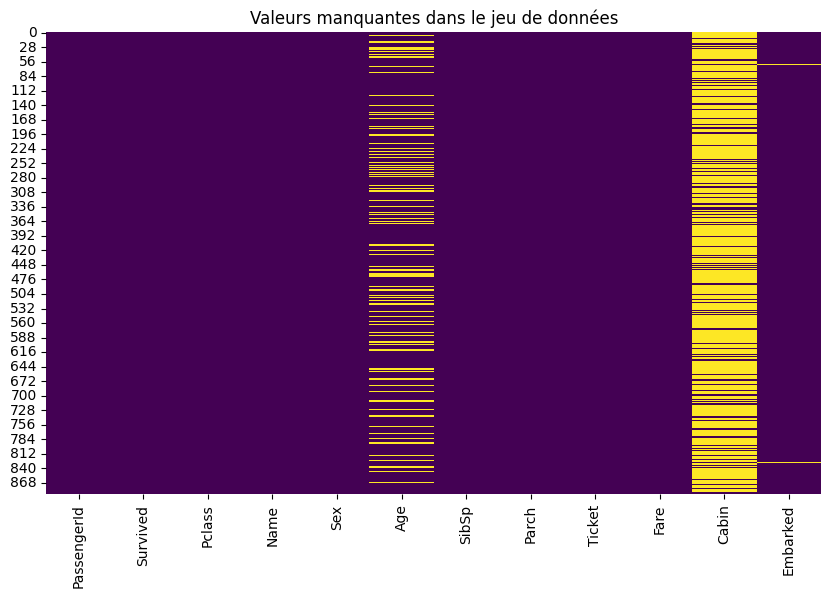

In [4]:
# Visualisation des valeurs manquantes
plt.figure(figsize=(10, 6))
sns.heatmap(train_data.isnull(), cbar=False, cmap='viridis')
plt.title('Valeurs manquantes dans le jeu de données')
plt.show()

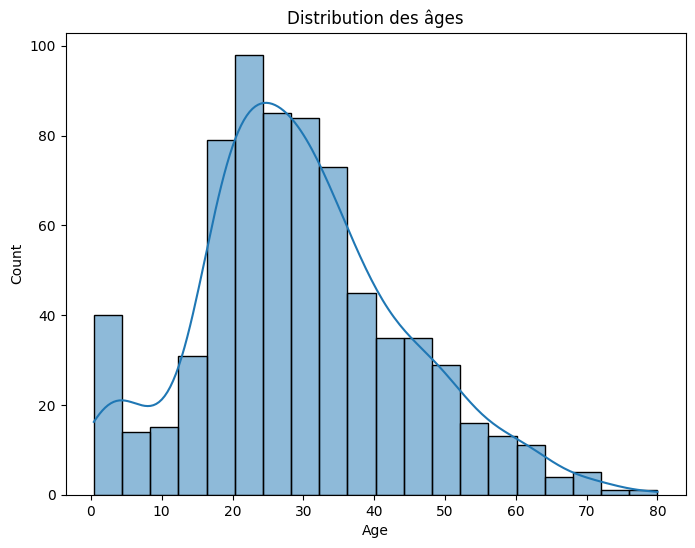

In [5]:
# Distribution des âges
plt.figure(figsize=(8, 6))
sns.histplot(train_data['Age'].dropna(), kde=True)
plt.title('Distribution des âges')
plt.show()

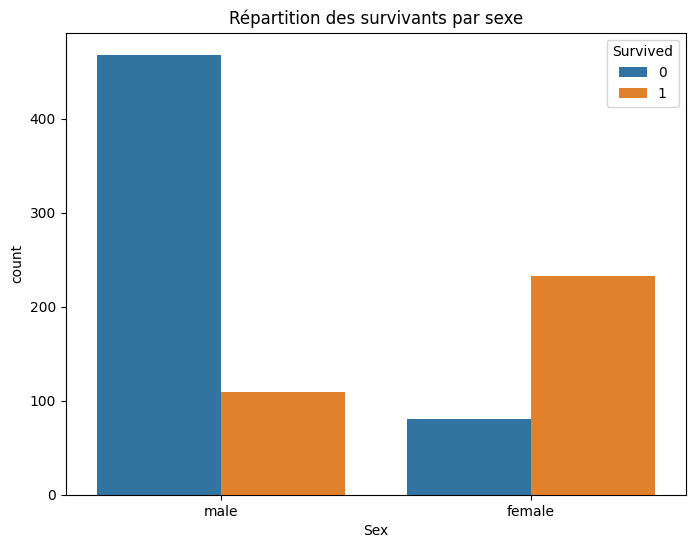

In [6]:
# Analyse des survivants par sexe
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='Survived', data=train_data)
plt.title('Répartition des survivants par sexe')
plt.show()

In [7]:
# Nettoyage des données
cleaned_data = clean_data(train_data)
print('Aperçu des données nettoyées:')
print(cleaned_data.head())

Aperçu des données nettoyées:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

      Fare  Embarked AgeGroup  
0   7.2500         2   Adulte  
1  71.2833         0   Adulte  
2   7.9250         2   Adulte  
3  53.1000         2   Adulte  
4   8.0500         2   Adulte  


In [8]:
# Préparation des données
X_train, X_test, y_train, y_test = prepare_data(cleaned_data, target_column='Survived')
print('Taille de X_train:', X_train.shape)
print('Taille de X_test:', X_test.shape)

Taille de X_train: (712, 902)
Taille de X_test: (179, 902)


In [9]:
# Entraînement du modèle
model = train_model(X_train, y_train)
print('Modèle entraîné avec succès.')

Modèle entraîné avec succès.


In [10]:
# Évaluation du modèle
evaluate_model(model, X_test, y_test)

Accuracy: 0.7988826815642458
Rapport de classification :
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.82      0.66      0.73        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.79       179



In [11]:
# Sauvegarde du modèle
save_model(model, 'models/final_model.pkl')
print('Modèle sauvegardé dans le fichier models/final_model.pkl.')

Modèle sauvegardé dans models/final_model.pkl.
Modèle sauvegardé dans le fichier models/final_model.pkl.


In [12]:
from domain.models import load_model
filename = 'models/final_model.pkl'
# load the model 
load_model = load_model(filename) 

In [ ]:
from domain.pipeline import prepare_data
df_test=pd.read_csv('../../../data/raw/test.csv')
df_test_prepared = prepare_data(df_test)
load_model.predict(df_test_prepared) # COmprendre pourquoi la colonne survived apparait